>
> # Scenario analysis - Market size (fixed supply/demand ratio)
>
> ## Visualisation
>
-----
Analyse the effect of variables on ridesourcing system performance

In [1]:
%load_ext autoreload
%autoreload 2
import os, zipfile
from dotmap import DotMap
import pandas as pd
import matplotlib.pyplot as plt
import math
import numpy as np
import json
from scipy.stats import t
import re
import seaborn as sns
from scenarios import *
from plot_func import *

In [2]:
# Enter variable and data type
# variable = {"name": "gini", "sym": "$G$", "int": False}
variable_1 = {"name": "nP", "sym": "$K$", "int": True, "pos": 2}
variable_2 = {"name": "nV", "sym": "$N$", "int": True, "pos": 4}
variables = {"variable_1": variable_1, "variable_2": variable_2}

In [3]:
# Loop through zip files
dir_name = os.path.join(os.getcwd(),'input','sampling')
# dir_name = os.path.join(os.getcwd(),'input',variable["name"])
res, micro, params, drivers, requests, var_val, all_pax = load_results(dir_name, variables)

# Find variable values that have been tested
vals, scn = find_vals(var_val, variables)

# Compute additional (aggregated) day-to-day indicators, incl. standard deviations, properties of agent groups, and relative indicators
res = add_indicators(micro, params, drivers, requests, res, all_pax)

In [4]:
vals_1 = set([i.split('_', 1)[0] for i in vals])
vals_2 = set([i.split('_', 1)[1] for i in vals])

abc_1 = set(map(int, [i.split('_', 1)[0] for i in vals]))
abc_2 = set(map(int, [i.split('_', 1)[1] for i in vals]))

In [5]:
# Find equilibrium values for all runs
conv_repl = determine_eql(res, params)
conv_repl['scn'] = var_val
conv_repl.head(3)

,t_sup*,perc_inc_reg*,t_dem*,perc_wait*,t*,converged,scn
0,40,82.921655,25,176.214993,40,True,120000_4000
1,32,84.420864,40,159.578474,40,True,120000_4000
2,27,82.367629,20,184.224227,27,True,120000_4000


In [6]:
# Convert indicators of individual runs to indicators for scenarios
eql_runs, eql_scn, d2d, params_scn = runs_to_scenarios(res, params, vals, scn)

Sufficient number of replications: 3/1 for scenario 120000_4000
Sufficient number of replications: 3/1 for scenario 150000_5000
Sufficient number of replications: 5/4 for scenario 15000_500
Sufficient number of replications: 3/1 for scenario 187500_6250
Sufficient number of replications: 4/1 for scenario 30000_1000
Sufficient number of replications: 35/11 for scenario 3750_125
Sufficient number of replications: 4/1 for scenario 45000_1500
Sufficient number of replications: 5/1 for scenario 60000_2000
Sufficient number of replications: 5/1 for scenario 75000_2500
Sufficient number of replications: 20/19 for scenario 7500_250
Sufficient number of replications: 3/1 for scenario 90000_3000


In [7]:
# Create d2d statistics
res_scn = d2d_stats(d2d, vals, res)

In [8]:
eql_scn.dem.head(5)

,inform,requests,gets_offer,accepts_offer,mean_wait,corr_mean_wait,perc_wait,perc_wait_req,bike,car,...,std_exp_wait,std_corr_wait,std_perc_wait_req,cons_surplus,pickup_time,match_time,corr_match_time,extra_bike,extra_pt,extra_car
scenario,,,,,,,,,,,,,,,,,,,,,
120000_4000,37470.333333,2841.600000,1.000000,2841.600000,106.782165,106.782165,124.317709,111.510190,25476.80,6830.333333,...,118.577323,118.577323,69.799300,2710.795390,108.354237,-1.572073,NaN,61329.666667,7952.666667,10595.666667
150000_5000,46789.666667,3602.466667,1.000000,3602.466667,98.589825,98.589825,110.782584,99.559664,31705.20,8548.133333,...,113.745064,113.745064,66.007214,3473.248609,100.164663,-1.574838,NaN,76481.000000,9989.666667,13364.666667
15000_500,4638.400000,172.440000,0.999565,172.360000,308.785142,309.415911,503.863314,398.300721,3270.24,900.760000,...,218.170941,219.695856,183.078932,60.435809,308.062692,0.722450,NaN,7655.200000,1029.800000,1345.600000
187500_6250,58553.333333,4600.266667,1.000000,4600.266667,87.292984,87.292984,99.410513,89.481647,39550.40,10731.866667,...,102.842003,102.842003,62.472696,4660.674892,88.863109,-1.570125,NaN,95491.666667,12560.333333,16689.333333
30000_1000,9302.250000,515.700000,0.999584,515.500000,228.604456,229.247028,285.716840,245.354579,6441.55,1754.450000,...,186.709981,188.666964,115.207950,320.292423,229.776873,-1.172417,NaN,15345.250000,1995.750000,2668.750000


In [9]:
eql_scn.sup.head(5)

,inform,regist,particip,mean_perc_inc,mean_perc_inc_ptcp,mean_perc_inc_reg,mean_exp_inc,rejected_reg,reject_particip,rel_perc_inc,...,driver_surplus,mean_rev,mean_op_costs,ivt_costs,dh_costs,mean_dh_dist,mean_dh_time,drive_time,not_idle_time,share_idle_time
scenario,,,,,,,,,,,,,,,,,,,,,
120000_4000,4000.0,305.066667,202.800000,78.503621,79.469816,78.581051,78.214879,0.0,0.0,0.589635,...,-18.662339,100.947724,22.732845,18.927968,3.804877,15.219509,1521.950863,7571.187079,9093.137942,0.684266
150000_5000,5000.0,385.666667,257.866667,78.352994,79.531247,78.349938,78.529690,0.0,0.0,0.594383,...,268.163754,100.976686,22.446996,18.943468,3.503528,14.014111,1401.411139,7577.387133,8978.798273,0.688236
15000_500,500.0,28.680000,13.880000,66.291138,66.620772,67.081467,61.691249,0.0,0.0,0.498743,...,-321.519974,87.865946,26.174697,16.381054,9.793643,39.174572,3917.457176,6552.421633,10469.878808,0.636463
187500_6250,6250.0,501.666667,331.200000,78.974666,79.971190,79.013432,78.571960,0.0,0.0,0.596157,...,40.714655,100.527241,21.955281,18.865233,3.090048,12.360192,1236.019178,7546.093025,8782.112203,0.695066
30000_1000,1000.0,61.800000,37.200000,73.563280,74.521235,74.215396,72.290384,0.0,0.0,0.550667,...,-277.131327,98.795532,26.505148,18.478470,8.026677,32.106710,3210.670973,7391.388165,10602.059137,0.631873


In [10]:
eql_scn.plf.head(5)

,plat_profit
120000_4000,6820.292500
150000_5000,8672.373625
15000_500,401.897925
187500_6250,11092.845175
30000_1000,1221.357694


In [11]:
# KPIs
kpis_sup = eql_scn.sup.columns
kpis_dem = eql_scn.dem.columns
kpis_plf = ['plat_profit']

In [12]:
# Add scenario values as columns to df
eql_scn.sup = add_scn_vals(eql_scn.sup, variables)
eql_scn.dem = add_scn_vals(eql_scn.dem, variables)
eql_scn.plf = add_scn_vals(eql_scn.plf, variables)

In [13]:
# Find societal value
eql_scn.soc = eql_scn.sup.driver_surplus + eql_scn.dem.cons_surplus + eql_scn.plf.plat_profit
eql_scn.soc = pd.DataFrame(eql_scn.soc.values, index = vals, columns = ['soc_value'])
eql_scn.soc = add_scn_vals(eql_scn.soc, variables)

IndexError: index 8 is out of bounds for axis 0 with size 8

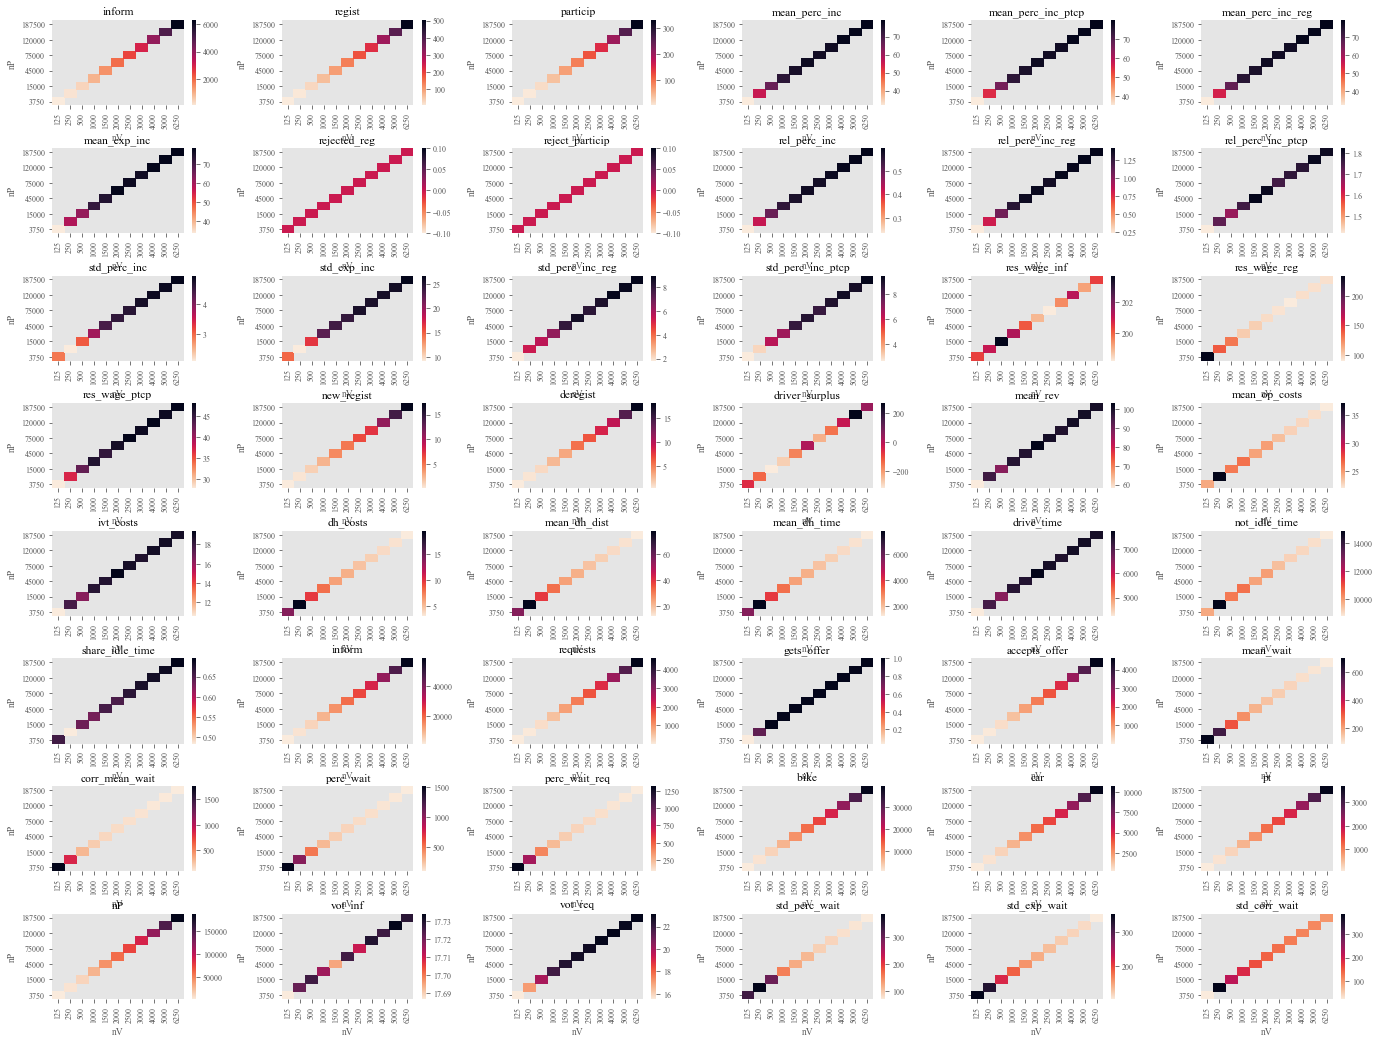

In [14]:
cmap = sns.cm.rocket_r
# Create pivot tables (incl. missing scenarios as NaNs)
fig, axes = plt.subplots(8, 6, figsize = [24,18])
    # plt.subplots_adjust(top=.9, bottom=.1, hspace=.1, left=.1, right=.9, wspace=.1)
fig.subplots_adjust(hspace=.5, wspace=0.4, left=.12, right=.88)

# sns.heatmap(eql_scn.sup.pivot(index='nP', columns='nV', values = 'inform'), ax=axes[0,0])
# axes[0, 1] = sns.heatmap(eql_scn.sup.pivot(index='nP', columns='nV', values = 'regist'))

i = 0
j = 0
for kpi in kpis_sup:
    axes[j, i] = sns.heatmap(eql_scn.sup.pivot(index='nP', columns='nV', values = kpi), ax=axes[j,i], cmap=cmap)
    axes[j, i].set_title(kpi)
    axes[j, i].invert_yaxis()
    i += 1
    if i > 5:
        i = 0
        j += 1

for kpi in kpis_dem:
    axes[j, i] = sns.heatmap(eql_scn.dem.pivot(index='nP', columns='nV', values = kpi), ax=axes[j,i], cmap=cmap)
    axes[j, i].set_title(kpi)
    axes[j, i].invert_yaxis()
    i += 1
    if i > 5:
        i = 0
        j += 1

for kpi in kpis_plf:
    axes[j, i] = sns.heatmap(eql_scn.plf.pivot(index='nP', columns='nV', values = kpi), ax=axes[j,i], cmap=cmap)
    axes[j, i].set_title(kpi)
    axes[j, i].invert_yaxis()
    i += 1
    if i > 5:
        i = 0
        j += 1
        
axes[j, i] = sns.heatmap(eql_scn.soc.pivot(index='nP', columns='nV', values = 'soc_value'), ax=axes[j,i], cmap=cmap)
axes[j, i].set_title('soc_value')
axes[j, i].invert_yaxis()
# kokos = eql_scn.sup.pivot(index='nP', columns='nV', values=['inform','regist'])
# sns.heatmap(data)
# sns.heatmap(kokos)
# plt.show()
fig.savefig(os.path.join(os.getcwd(),"plots",variable_1["name"] + '-' + variable_2["name"], 'heat_maps.jpg'),dpi=300,bbox_inches='tight')

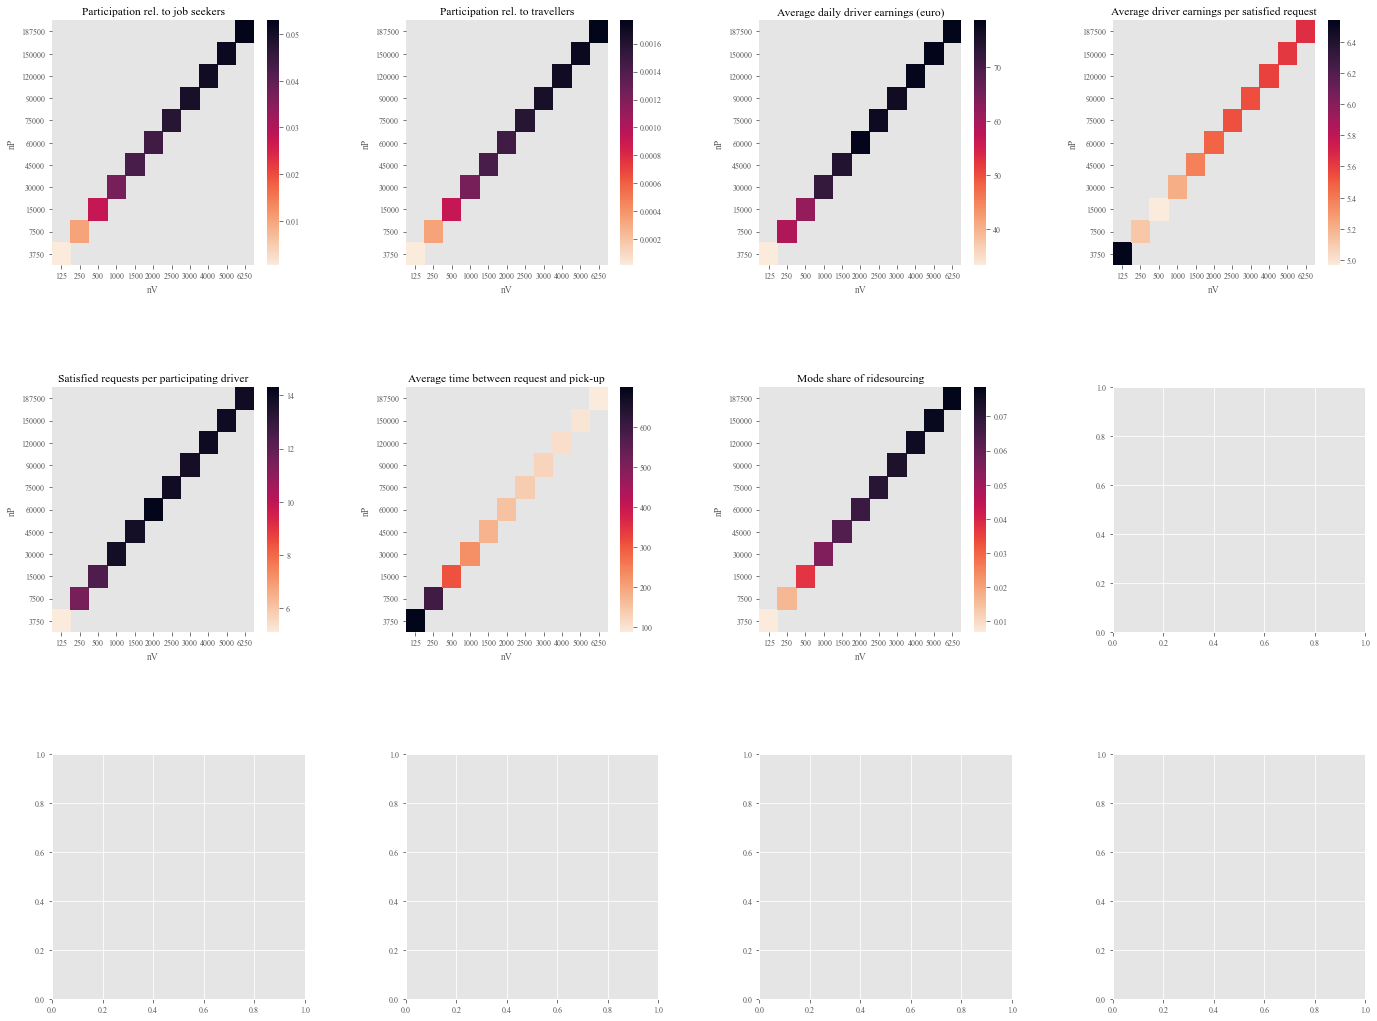

In [15]:
cmap = sns.cm.rocket_r
# Create pivot tables (incl. missing scenarios as NaNs)
fig, axes = plt.subplots(3, 4, figsize = [24,18])
    # plt.subplots_adjust(top=.9, bottom=.1, hspace=.1, left=.1, right=.9, wspace=.1)
fig.subplots_adjust(hspace=.5, wspace=0.4, left=.12, right=.88)

# sns.heatmap(eql_scn.sup.pivot(index='nP', columns='nV', values = 'inform'), ax=axes[0,0])
# axes[0, 1] = sns.heatmap(eql_scn.sup.pivot(index='nP', columns='nV', values = 'regist'))

res_proc = pd.DataFrame(index = eql_scn.sup.index)
res_proc['nP'] = eql_scn.sup.nP
res_proc['nV'] = eql_scn.sup.nV

res_proc['part_inf'] = eql_scn.sup.particip / eql_scn.sup.inform
axes[0,0] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='part_inf'), ax = axes[0,0], cmap=cmap)
axes[0,0].set_title('Participation rel. to job seekers')
axes[0,0].invert_yaxis()
# axes[1,2].yaxis.set_major_formatter(mtick.PercentFormatter(1)) 

res_proc['part_inf'] = eql_scn.sup.particip / res_proc.nP
axes[0,1] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='part_inf'), ax = axes[0,1], cmap=cmap)
axes[0,1].set_title('Participation rel. to travellers')
axes[0,1].invert_yaxis()
# axes[1,2].yaxis.set_major_formatter(mtick.PercentFormatter(1)) 

res_proc['part_inf'] = eql_scn.dem.requests / eql_scn.dem.inform
axes[1,2] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='part_inf'), ax = axes[1,2], cmap=cmap)
axes[1,2].set_title('Mode share of ridesourcing')
axes[1,2].invert_yaxis()
# axes[1,3].yaxis.set_major_formatter(mtick.PercentFormatter(1))  

res_proc['exp_inc'] = eql_scn.sup.mean_exp_inc.copy()
axes[0,2] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='exp_inc'), ax = axes[0,2], cmap=cmap)
axes[0,2].set_title('Average daily driver earnings (euro)')
axes[0,2].invert_yaxis()

res_proc['earn_req_sat'] = eql_scn.sup.mean_exp_inc * eql_scn.sup.particip / (eql_scn.dem.requests * eql_scn.dem.gets_offer)
axes[0,3] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='earn_req_sat'), ax = axes[0,3], cmap=cmap)
axes[0,3].set_title('Average driver earnings per satisfied request')
axes[0,3].invert_yaxis()


res_proc['serv_req_part'] = eql_scn.dem.gets_offer * eql_scn.dem.requests / eql_scn.sup.particip 
axes[1,0] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='serv_req_part'), ax = axes[1,0], cmap=cmap)
axes[1,0].set_title('Satisfied requests per participating driver')
axes[1,0].invert_yaxis()

res_proc['wait_time'] = eql_scn.dem.mean_wait
axes[1,1] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='wait_time'), ax = axes[1,1], cmap=cmap)
axes[1,1].set_title('Average time between request and pick-up')
axes[1,1].invert_yaxis()

fig.savefig(os.path.join(os.getcwd(),"plots",variable_1["name"] + '-' + variable_2["name"], 'heat_maps_select.jpg'),dpi=300,bbox_inches='tight')

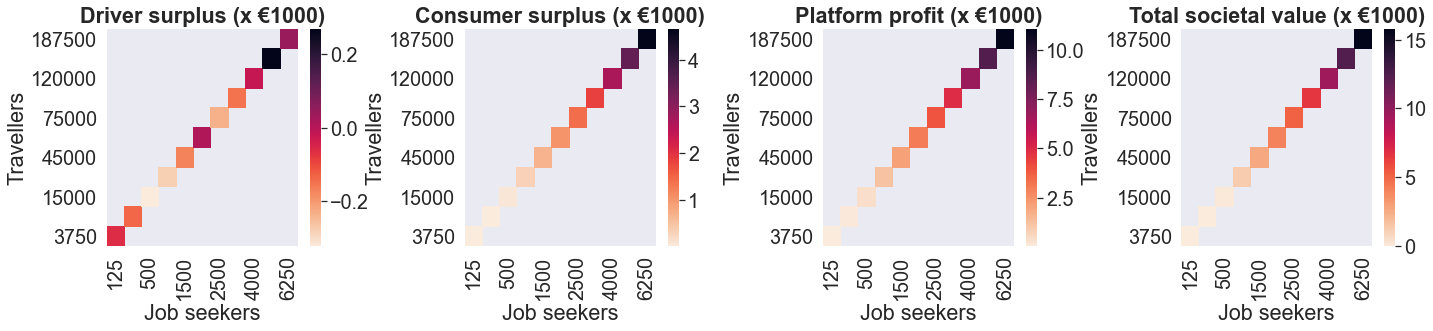

In [16]:
sns.set(font_scale=1.8)
plt.rcParams['font.weight'] = "normal"
cmap = sns.cm.rocket_r
# Create pivot tables (incl. missing scenarios as NaNs)
fig, axes = plt.subplots(1, 4, figsize = [24,4])
    # plt.subplots_adjust(top=.9, bottom=.1, hspace=.1, left=.1, right=.9, wspace=.1)
fig.subplots_adjust(hspace=.5, wspace=0.5, left=.12, right=.88)

axes[0] = sns.heatmap(eql_scn.sup.pivot(index=variable_1['name'], columns=variable_2['name'], values='driver_surplus')/1000, ax = axes[0], cmap=cmap)
axes[0].set_title('Driver surplus (x \u20ac1000)',fontweight="bold")
axes[0].invert_yaxis()
axes[0].set_xlabel('Job seekers')
axes[0].set_ylabel('Travellers')
# axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(10))

axes[1] = sns.heatmap(eql_scn.dem.pivot(index=variable_1['name'], columns=variable_2['name'], values='cons_surplus')/1000, ax = axes[1], cmap=cmap)
axes[1].set_title('Consumer surplus (x \u20ac1000)',fontweight="bold")
axes[1].invert_yaxis()
axes[1].set_xlabel('Job seekers')
axes[1].set_ylabel('Travellers')

axes[2] = sns.heatmap(eql_scn.plf.pivot(index=variable_1['name'], columns=variable_2['name'], values='plat_profit')/1000, ax = axes[2], cmap=cmap)
axes[2].set_title('Platform profit (x \u20ac1000)',fontweight="bold")
axes[2].invert_yaxis()
axes[2].set_xlabel('Job seekers')
axes[2].set_ylabel('Travellers')

axes[3] = sns.heatmap(eql_scn.soc.pivot(index=variable_1['name'], columns=variable_2['name'], values='soc_value')/1000, ax = axes[3], cmap=cmap)
axes[3].set_title('Total societal value (x \u20ac1000)',fontweight="bold")
axes[3].invert_yaxis()
axes[3].set_xlabel('Job seekers')
axes[3].set_ylabel('Travellers')

fig.savefig(os.path.join(os.getcwd(),"plots",variable_1["name"] + '-' + variable_2["name"], '{}-{}_societal_value.jpg'.format(variable_1["name"],variable_2["name"])),dpi=300,bbox_inches='tight')

---

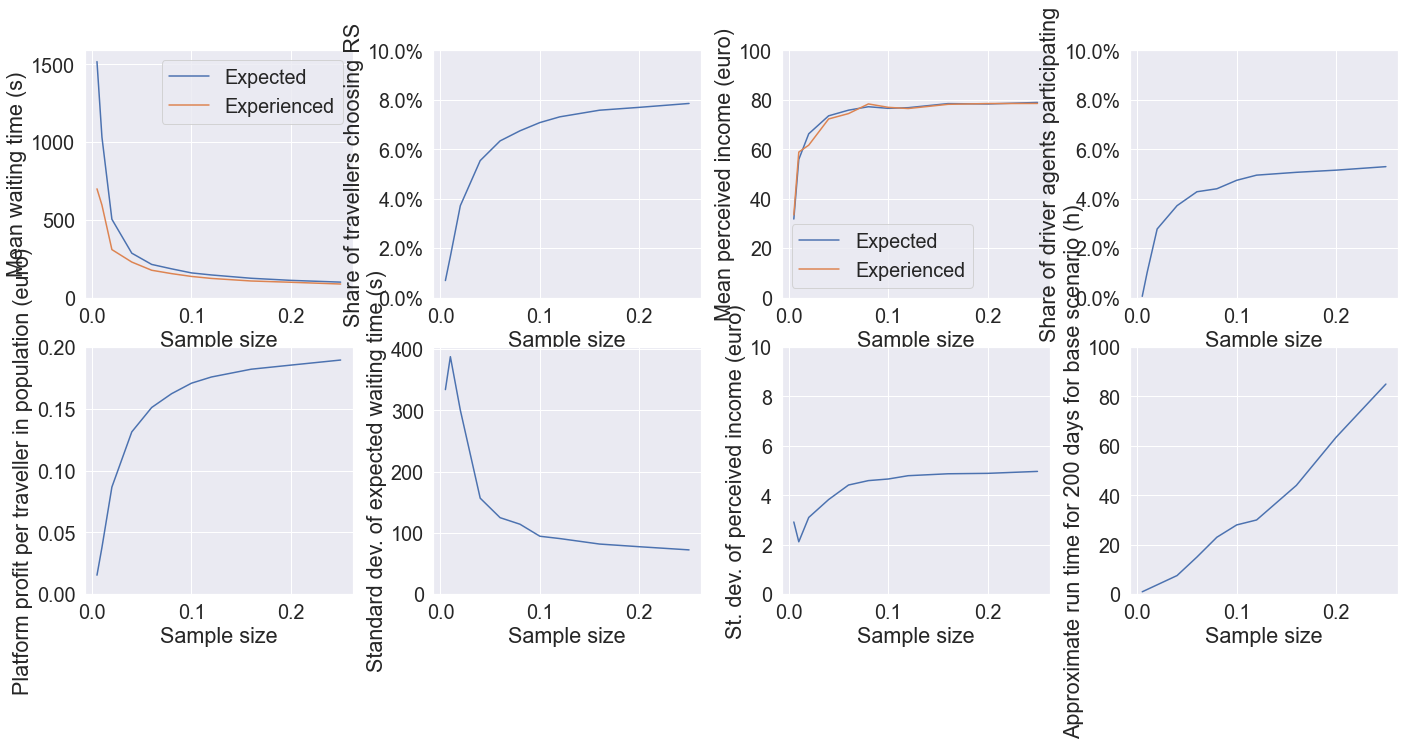

In [17]:
# Investigating diagonal (for determination of representative sample size)
indices = [0.005,0.01,0.02,0.04,0.06,0.08,0.1,0.12,0.16,0.2,0.25]
labels = ['3750_125','7500_250','15000_500','30000_1000','45000_1500','60000_2000','75000_2500','90000_3000','120000_4000','150000_5000','187500_6250']

scal_sup = eql_scn.sup.loc(axis=0)[labels]
scal_sup.index = indices
scal_dem = eql_scn.dem.loc(axis=0)[labels]
scal_dem.index = indices
scal_plf = eql_scn.plf.loc(axis=0)[labels]
scal_plf.index = indices
# eql_scn.sup.loc['75000_2500'] / eql_scn.sup.loc['15000_500']
# eql_scn.dem.loc['75000_2500'] / eql_scn.dem.loc['15000_500']
# eql_scn.sup.loc['75000_2500'] / eql_scn.sup.loc['45000_1500']
# eql_scn.dem.loc['75000_2500'] / eql_scn.dem.loc['45000_1500']
# scal_sup.particip.plot()
# scal_sup.mean_perc_inc.plot()
# scal_dem.mean_wait.plot()

fig, axes = plt.subplots(2, 4, figsize = [24,10])
    # plt.subplots_adjust(top=.9, bottom=.1, hspace=.1, left=.1, right=.9, wspace=.1)
fig.subplots_adjust(hspace=.2, wspace=0.3, left=.12, right=.88)

axes[0,0] = (scal_dem.perc_wait).plot(ax = axes[0,0], label='Expected')
axes[0,0] = (scal_dem.mean_wait).plot(ax = axes[0,0], label= 'Experienced')
axes[0,0].set_ylabel('Mean waiting time (s)')
axes[0,0].set_xlabel('Sample size')
axes[0, 0].set_ylim(bottom = 0) 
axes[0,0].legend()

axes[0,1] = (scal_dem.requests / scal_dem.inform).plot(ax = axes[0,1])
axes[0,1].set_ylabel('Share of travellers choosing RS')
axes[0,1].set_xlabel('Sample size')
axes[0,1].yaxis.set_major_formatter(mtick.PercentFormatter(1))
axes[0, 1].set_ylim(bottom = 0, top = 0.1)

axes[0,2] = (scal_sup.mean_perc_inc).plot(ax = axes[0,2], label = 'Expected')
axes[0,2] = (scal_sup.mean_exp_inc).plot(ax = axes[0,2], label = 'Experienced')
axes[0,2].set_ylabel('Mean perceived income (euro)')
axes[0,2].set_xlabel('Sample size')
# axes[0,2].yaxis.set_major_formatter(mtick.PercentFormatter(1))
axes[0, 2].set_ylim(bottom = 0, top = 100)
axes[0,2].legend()

axes[0,3] = (scal_sup.particip / scal_sup.inform).plot(ax = axes[0,3])
axes[0,3].set_ylabel('Share of driver agents participating')
axes[0,3].set_xlabel('Sample size')
axes[0,3].yaxis.set_major_formatter(mtick.PercentFormatter(1))
axes[0, 3].set_ylim(bottom = 0, top = 0.1) 

axes[1,0] = (scal_plf.plat_profit / scal_dem.inform).plot(ax = axes[1,0])
axes[1,0].set_ylabel('Platform profit per traveller in population (euro)')
axes[1,0].set_xlabel('Sample size')
# axes[1,0].yaxis.set_major_formatter(mtick.PercentFormatter(1))
axes[1, 0].set_ylim(bottom = 0, top =0.2) 

axes[1,1] = (scal_dem.std_perc_wait).plot(ax = axes[1,1])
axes[1,1].set_ylabel('Standard dev. of expected waiting time (s)')
axes[1,1].set_xlabel('Sample size')
# axes[1,0].yaxis.set_major_formatter(mtick.PercentFormatter(1))
axes[1, 1].set_ylim(bottom = 0) 

axes[1,2] = (scal_sup.std_perc_inc).plot(ax = axes[1,2])
axes[1,2].set_ylabel('St. dev. of perceived income (euro)')
axes[1,2].set_xlabel('Sample size')
# axes[1,0].yaxis.set_major_formatter(mtick.PercentFormatter(1))
axes[1, 2].set_ylim(bottom = 0, top = 10) 

appr_runtime = pd.Series(index = indices, data = [0.9375, 1.875, 3.75, 7.5, 15, 23, 28, 30, 44, 63.5, 85])
axes[1,3] = (appr_runtime).plot(ax = axes[1,3])
axes[1,3].set_ylabel('Approximate run time for 200 days for base scenario (h)')
axes[1,3].set_xlabel('Sample size')
# axes[1,0].yaxis.set_major_formatter(mtick.PercentFormatter(1))
axes[1, 3].set_ylim(bottom = 0, top = 100) 

fig.savefig(os.path.join(os.getcwd(),"plots",'sample_effect.jpg'),dpi=300,bbox_inches='tight')

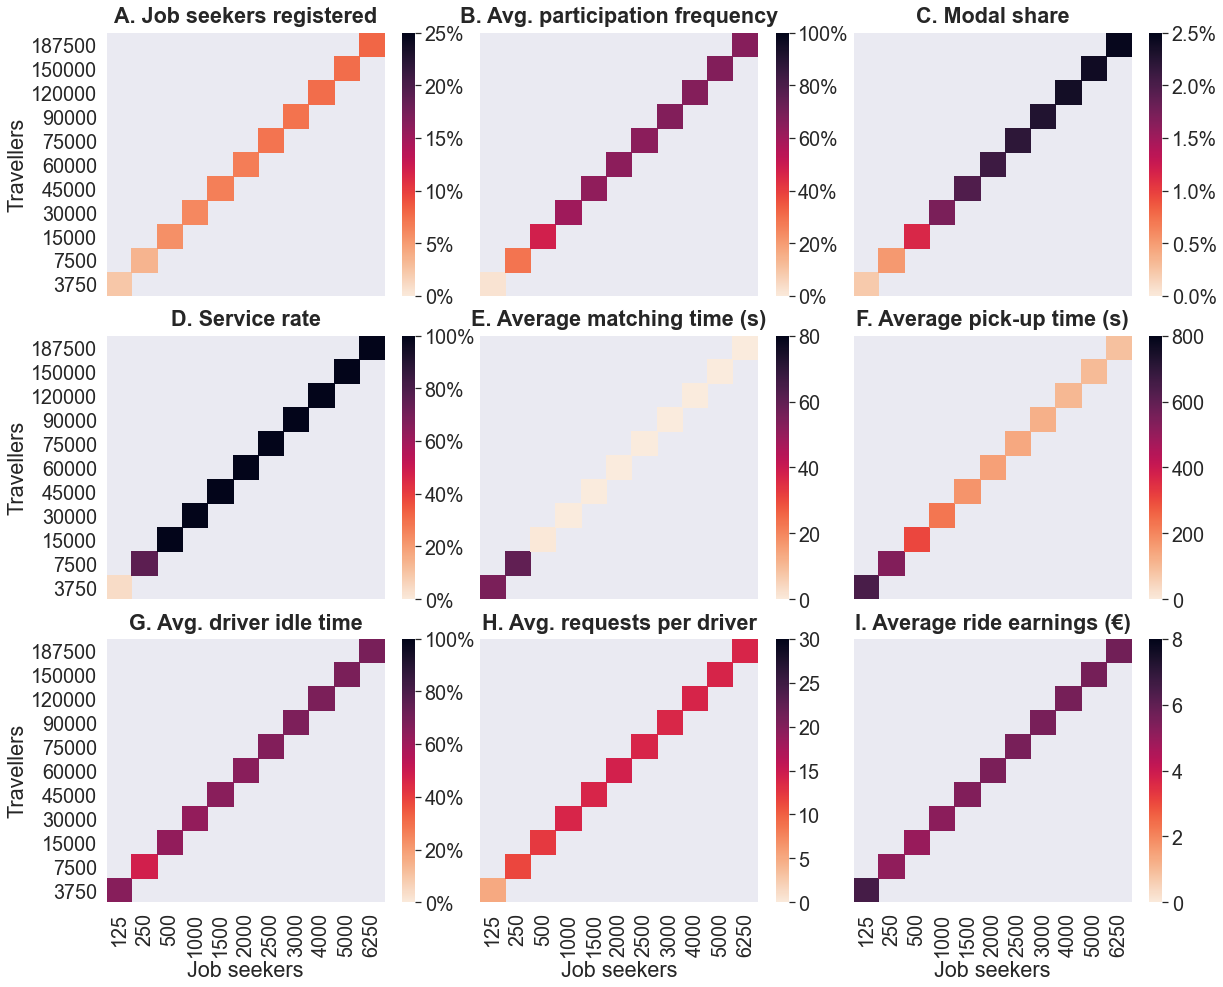

In [18]:
cmap = sns.cm.rocket_r
sns.set(font_scale=1.8)
plt.rcParams['font.weight'] = "normal"
# Create pivot tables (incl. missing scenarios as NaNs)
fig, axes = plt.subplots(3, 3, figsize = [20,16], sharex=True, sharey=True)
    # plt.subplots_adjust(top=.9, bottom=.1, hspace=.1, left=.1, right=.9, wspace=.1)
fig.subplots_adjust(hspace=.15, wspace=0.075, left=.12, right=.88)

res_proc = pd.DataFrame(index = eql_scn.sup.index)
res_proc['nP'] = eql_scn.sup.nP
res_proc['nV'] = eql_scn.sup.nV


res_proc['mode_share'] = eql_scn.dem.requests / eql_scn.dem.nP # eql_scn.dem.inform
axes[0,2] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='mode_share'), ax = axes[0,2], cmap=cmap, vmin=0, vmax=0.025)
cbar = axes[0,2].collections[0].colorbar
cbar.ax.yaxis.set_major_formatter(PercentFormatter(1, 1))
axes[0,2].set_title('C. Modal share', fontweight="bold", pad=10)
axes[0,2].invert_yaxis()
axes[0,2].set_xlabel('Job seekers')
axes[0,2].set_ylabel('Travellers')
axes[0,2].xaxis.label.set_visible(False)
axes[0,2].yaxis.label.set_visible(False)

res_proc['earn_req_sat'] = eql_scn.sup.mean_exp_inc * eql_scn.sup.particip / (eql_scn.dem.requests * eql_scn.dem.gets_offer)
axes[2,2] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='earn_req_sat'), ax = axes[2,2], cmap=cmap, vmin=0.0, vmax=8.0)
axes[2,2].set_title('I. Average ride earnings (\u20ac)', fontweight="bold", pad=10)
axes[2,2].invert_yaxis()
axes[2,2].set_xlabel('Job seekers')
axes[2,2].set_ylabel('Travellers')
axes[2,2].yaxis.label.set_visible(False)

res_proc['serv_req_part'] = eql_scn.dem.gets_offer * eql_scn.dem.requests / eql_scn.sup.particip 
axes[2,1] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='serv_req_part'), ax = axes[2,1], cmap=cmap, vmin=0, vmax=30)
axes[2,1].set_title('H. Avg. requests per driver', fontweight="bold", pad=10)
axes[2,1].invert_yaxis()
axes[2,1].set_xlabel('Job seekers')
axes[2,1].set_ylabel('Travellers')
axes[2,1].yaxis.label.set_visible(False)

res_proc['idle_time'] = eql_scn.sup.share_idle_time
axes[2,0] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='idle_time'), ax = axes[2,0], cmap=cmap, vmin=0, vmax=1)
axes[2,0].set_title('G. Avg. driver idle time', fontweight="bold", pad=10)
cbar = axes[2,0].collections[0].colorbar
cbar.ax.yaxis.set_major_formatter(PercentFormatter(1, 0))
axes[2,0].invert_yaxis()
axes[2,0].set_xlabel('Job seekers')
axes[2,0].set_ylabel('Travellers')

res_proc['regist'] = eql_scn.sup.regist / eql_scn.sup.inform
axes[0,0] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='regist'), ax = axes[0,0], cmap=cmap, vmin=0, vmax=0.25)
cbar = axes[0,0].collections[0].colorbar
cbar.ax.yaxis.set_major_formatter(PercentFormatter(1, 0))
axes[0,0].set_title('A. Job seekers registered', fontweight="bold", pad=10)
axes[0,0].invert_yaxis()
axes[0,0].set_xlabel('Job seekers')
axes[0,0].set_ylabel('Travellers')
axes[0,0].xaxis.label.set_visible(False)

res_proc['ptcp_prob'] = eql_scn.sup.particip / eql_scn.sup.regist
axes[0,1] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='ptcp_prob'), ax = axes[0,1], cmap=cmap, vmin=0, vmax=1)
cbar = axes[0,1].collections[0].colorbar
cbar.ax.yaxis.set_major_formatter(PercentFormatter(1, 0))
axes[0,1].set_title('B. Avg. participation frequency', fontweight="bold", pad=10)
axes[0,1].invert_yaxis()
axes[0,1].set_xlabel('Job seekers')
axes[0,1].set_ylabel('Travellers')
axes[0,1].xaxis.label.set_visible(False)
axes[0,1].yaxis.label.set_visible(False)

res_proc['match_rate'] = eql_scn.dem.gets_offer.copy()
axes[1,0] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='match_rate'), ax = axes[1,0], cmap=cmap, vmin=0, vmax=1)
cbar = axes[1,0].collections[0].colorbar
cbar.ax.yaxis.set_major_formatter(PercentFormatter(1, 0))
axes[1,0].set_title('D. Service rate', fontweight="bold", pad=10)
axes[1,0].invert_yaxis()
axes[1,0].set_xlabel('Job seekers')
axes[1,0].set_ylabel('Travellers')
axes[1,0].xaxis.label.set_visible(False)

res_proc['match_time'] = eql_scn.dem.match_time.copy()
axes[1,1] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='match_time'), ax = axes[1,1], cmap=cmap, vmin=0, vmax=80)
axes[1,1].set_title('E. Average matching time (s)', fontweight="bold", pad=10)
axes[1,1].invert_yaxis()
axes[1,1].set_xlabel('Job seekers')
axes[1,1].set_ylabel('Travellers')
axes[1,1].xaxis.label.set_visible(False)
axes[1,1].yaxis.label.set_visible(False)

res_proc['pickup_time'] = eql_scn.dem.pickup_time.copy()
axes[1,2] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='pickup_time'), ax = axes[1,2], cmap=cmap, vmin=0, vmax=800)
axes[1,2].set_title('F. Average pick-up time (s)', fontweight="bold", pad=10)
axes[1,2].invert_yaxis()
axes[1,2].set_xlabel('Job seekers')
axes[1,2].set_ylabel('Travellers')
axes[1,2].yaxis.label.set_visible(False)
axes[1,2].xaxis.label.set_visible(False)

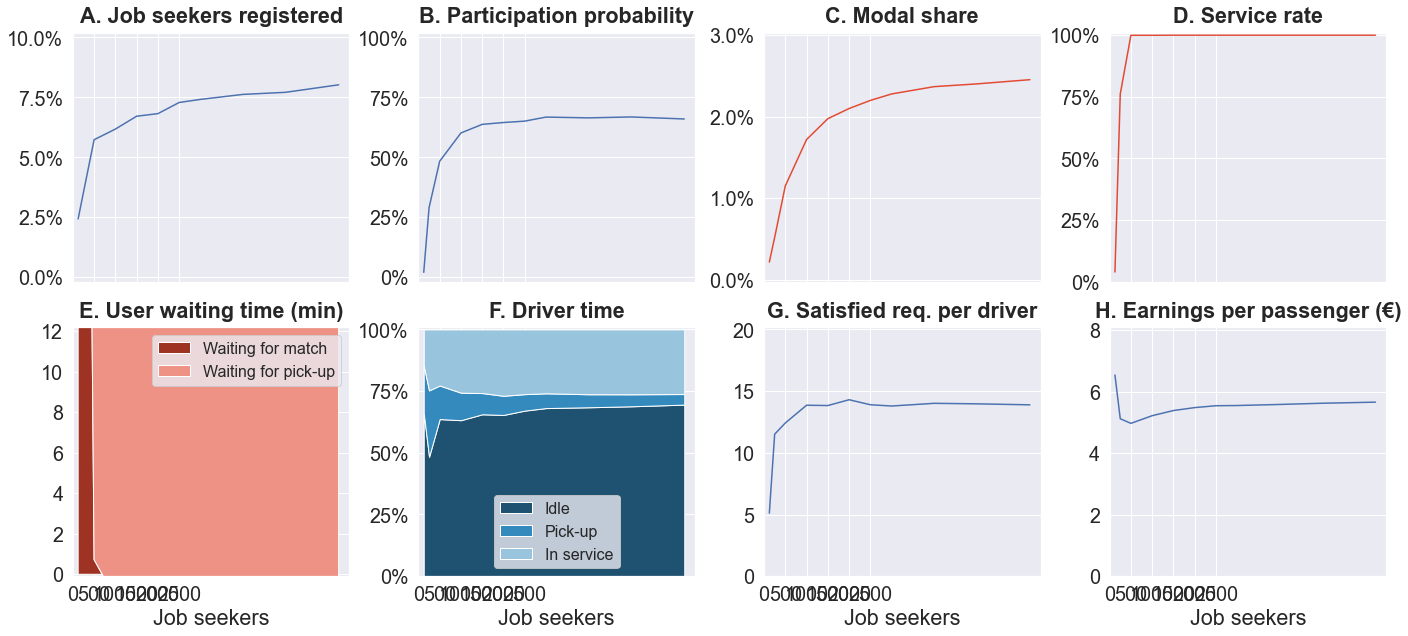

In [19]:
fig, axes = plt.subplots(2, 4, figsize = [24,10],sharex=True)
# plt.subplots_adjust(top=.9, bottom=.1, hspace=.1, left=.1, right=.9, wspace=.1)
fig.subplots_adjust(hspace=.18, wspace=0.25, left=.12, right=.88)
plt.setp(axes, xlim=[0,6500],xticks=np.arange(0, 3000, step=500))


res_proc.sort_values(by=['nP']).plot(x='nV',y='regist',ax=axes[0,0],legend=None, marker=None)
axes[0, 0].set_xlabel('Job seekers')
axes[0, 0].set_title('A. Job seekers registered',fontweight="bold",pad=10)
axes[0, 0].set_ylim(bottom = -0.002, top = 0.102)
axes[0, 0].yaxis.set_major_formatter(mtick.PercentFormatter(1)) 
axes[0, 0].locator_params(axis='y', nbins=5)

res_proc.sort_values(by=['nP']).plot(x='nV',y='ptcp_prob',ax=axes[0,1],legend=None, marker=None)
axes[0, 1].set_xlabel('nV')
axes[0, 1].set_title('B. Participation probability',fontweight="bold",pad=10)
axes[0, 1].set_ylim(bottom = -0.02, top = 1.02)
axes[0, 1].yaxis.set_major_formatter(mtick.PercentFormatter(1)) 
axes[0, 1].locator_params(axis='y', nbins=5)

res_proc.sort_values(by=['nP']).plot(x='nV',y='mode_share',ax=axes[0,2],legend=None, marker=None,color="#e24a33")
axes[0, 2].set_title('C. Modal share', fontweight="bold",pad=10)
axes[0, 2].set_ylim(bottom = -0.0003, top = 0.0303)
axes[0, 2].yaxis.set_major_formatter(mtick.PercentFormatter(1,decimals=1)) 
axes[0, 2].locator_params(axis='y', nbins=4)

res_proc.sort_values(by=['nP']).plot(x='nV',y='match_rate',ax=axes[0,3],legend=None, marker=None,color="#e24a33")
axes[0, 3].set_xlabel('nV')
axes[0, 3].set_title('D. Service rate', fontweight="bold",pad=10)
axes[0, 3].set_ylim(bottom = -0.001, top = 1.01)
axes[0, 3].yaxis.set_major_formatter(mtick.PercentFormatter(1)) 
axes[0, 3].locator_params(axis='y', nbins=5)

axes[1, 0].set_xlabel('Job seekers')
axes[1, 0].set_title('E. User waiting time (min)', fontweight="bold",pad=10)
axes[1, 0].set_ylim(bottom = -2, top = 100)
axes[1, 0].locator_params(axis='y', nbins=5)

x = res_proc.sort_values(by=['nP'])['nV']
y1 = res_proc.sort_values(by=['nP'])['match_time']
y2 = res_proc.sort_values(by=['nP'])['pickup_time']
colors=["#9e3323","#ed9284"]
axes[1, 0].stackplot(x,y1,y2, alpha=1, colors=colors)
axes[1, 0].legend(['Waiting for match','Waiting for pick-up'],fontsize=16)

axes[1, 0].set_xlabel('Job seekers')
axes[1, 0].set_ylim(bottom = -0.1, top = 12.2)
axes[1, 0].locator_params(axis='y', nbins=7)

res_proc['dh_time'] = eql_scn.sup.mean_dh_time / (params[0]['simTime'] * 3600)
x = res_proc.sort_values(by=['nP'])['nV']
y1 = res_proc.sort_values(by=['nP'])['idle_time']
y2 = res_proc.sort_values(by=['nP'])['dh_time']
y3 = 1 - y1 - y2
colors=["#1f5271","#348abd","#99c4de"]
axes[1, 1].stackplot(x,y1,y2,y3, alpha=1,colors=colors)
axes[1, 1].legend(['Idle','Pick-up','In service'],loc='lower center',fontsize=16)


axes[1, 1].set_xlabel('Job seekers')
axes[1, 1].set_title('F. Driver time', fontweight="bold",pad=10)
axes[1, 1].set_ylim(bottom = -0.001, top = 1.01)
axes[1, 1].yaxis.set_major_formatter(mtick.PercentFormatter(1)) 
axes[1, 1].locator_params(axis='y', nbins=5)


res_proc.sort_values(by=['nP']).plot(x='nV',y='serv_req_part',ax=axes[1,2],legend=None, marker=None)
axes[1, 2].set_xlabel('Job seekers')
axes[1, 2].set_title('G. Satisfied req. per driver',fontweight="bold",pad=10)
axes[1, 2].set_ylim(bottom = -0.002, top = 20.2)
axes[1, 2].locator_params(axis='y', nbins=5)

res_proc.sort_values(by=['nP']).plot(x='nV',y='earn_req_sat',ax=axes[1,3],legend=None, marker=None)
axes[1, 3].set_xlabel('Job seekers')
axes[1, 3].set_title('H. Earnings per passenger (€)', fontweight="bold",pad=10)
axes[1, 3].set_ylim(bottom = -0.001, top = 8.1)
axes[1, 3].locator_params(axis='y', nbins=5)

fig.savefig(os.path.join(os.getcwd(),"plots",variable_1["name"] + '-' + variable_2["name"], 'msize_fix-ratio.jpg'),dpi=300,bbox_inches='tight')